# Limpieza y Preparación de Datos — Tendencias de YouTube (EE. UU.)

Notebook que toma el CSV **crudo** (`USvideos_cc50_202101.csv`), aplica una limpieza
documentada y genera un dataset **listo para modelar**.

- **Variable objetivo (target):** `likes` (una de las 4 sugeridas por el enunciado).
- **Grano:** panel completo (se conservan las apariciones de un mismo video en días de
  tendencia distintos; solo se eliminan duplicados exactos y por `(video_id, trending_date)`).
- **Regla anti-fuga:** como se predice `likes`, se **excluye** `like_view_ratio`
  (`likes/views`) de las variables del modelo. Los ratios que no contienen `likes`
  (`dislike_view_ratio`, `comment_view_ratio`) sí son válidos.

Se parte siempre del CSV crudo, no de estados intermedios.

## Flujo
1. Setup y carga
2. Deduplicación (panel)
3. Fechas y `days_to_trend`
4. Consistencia: negativos y reglas de negocio
5. Nulos
5.5 **Checkpoint** intermedio y re-análisis de variables
6. Ingeniería de variables (sin leakage)
7. Selección de columnas y exportación

## 1. Setup y carga

Importamos librerías, resolvemos la ruta de datos con `pathlib` (funciona desde
`notebooks/` o desde la raíz) y cargamos el CSV crudo cruzándolo con el catálogo de
categorías (`US_category_id.json`) para obtener `category_name`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
plt.style.use("ggplot")
sns.set_palette("husl")
%matplotlib inline

# Resolver la raiz del repositorio buscando la carpeta 'dataset/'
ROOT = Path.cwd()
while not (ROOT / "dataset").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

CSV_PATH = ROOT / "dataset" / "USvideos_cc50_202101.csv"
JSON_PATH = ROOT / "dataset" / "US_category_id.json"

# Rutas de salida
CLEAN_BASE_PATH = ROOT / "dataset" / "USvideos_clean_base.csv"   # checkpoint (post-limpieza)
CLEAN_MODEL_PATH = ROOT / "dataset" / "USvideos_clean.csv"        # dataset final (model-ready)

print("Raiz del repo:", ROOT)
print("CSV crudo:", CSV_PATH.exists(), "| JSON:", JSON_PATH.exists())

Raiz del repo: d:\UPChexk\2026-I\Fundamentos_Data_Science\TFF\1ACC0216-TB2-2026-1
CSV crudo: True | JSON: True


In [2]:
# Carga del CSV crudo + merge con el catalogo de categorias
df = pd.read_csv(CSV_PATH)

with open(JSON_PATH, "r", encoding="utf-8") as f:
    categories_data = json.load(f)
category_mapping = {
    int(item["id"]): item["snippet"]["title"] for item in categories_data["items"]
}
df["category_name"] = df["category_id"].map(category_mapping)

# Registro para el reporte final y contadores de filas eliminadas por motivo
n_filas_inicial = len(df)
descartes = {}

print(f"Filas iniciales: {n_filas_inicial:,} | Columnas: {df.shape[1]}")
df.head()

Filas iniciales: 40,949 | Columnas: 21


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category_name
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,Utah,39.419220,-111.950684,POINT (-111.950684 39.41922),People & Blogs
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Nevada,39.876019,-117.224121,POINT (-117.224121 39.876019),Entertainment
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,Delaware,39.000000,-75.500000,POINT (-75.5 39),Comedy
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Delaware,39.000000,-75.500000,POINT (-75.5 39),Entertainment
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Michigan,44.182205,-84.506836,POINT (-84.50683600000001 44.182205),Entertainment


## 2. Deduplicación (panel)

Eliminamos duplicados **exactos** (filas idénticas en todas las columnas) y duplicados
por `(video_id, trending_date)` (mismo video, mismo día = registro redundante),
conservando la primera aparición. **No** colapsamos las apariciones legítimas de un
mismo video en días de tendencia distintos: eso es parte de la naturaleza del panel.

In [3]:
# 2.1 Duplicados exactos
antes = len(df)
df = df.drop_duplicates()
descartes["duplicados_exactos"] = antes - len(df)

# 2.2 Duplicados por (video_id, trending_date), conservando el primero
antes = len(df)
df = df.drop_duplicates(subset=["video_id", "trending_date"], keep="first")
descartes["duplicados_video_fecha"] = antes - len(df)

print(f"Eliminados por duplicado exacto: {descartes['duplicados_exactos']}")
print(f"Eliminados por (video_id, trending_date): {descartes['duplicados_video_fecha']}")
print(f"Filas restantes: {len(df):,}")

Eliminados por duplicado exacto: 1
Eliminados por (video_id, trending_date): 49
Filas restantes: 40,899


## 3. Fechas y `days_to_trend`

Parseamos `trending_date` (formato `YY.DD.MM`) y `publish_time`, y construimos la
variable derivada `days_to_trend` = días entre la publicación y la entrada en tendencia.
Luego diagnosticamos su distribución para separar dos cosas distintas:

- **Valores negativos** → datos imposibles (tendencia antes de publicar): se descartan.
- **Extremos positivos** → outliers reales (videos antiguos que reingresan a tendencia):
  no se borran; se tratarán con `log1p` y, si hace falta, un cap por percentil.

In [4]:
# Parseo de fechas
df["trending_date"] = pd.to_datetime(df["trending_date"], format="%y.%d.%m", errors="coerce")
# publish_time viene con zona horaria (UTC); la quitamos para poder restar con trending_date
df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce", utc=True).dt.tz_localize(None)

# Variable derivada: dias desde la publicacion hasta la tendencia.
# Se compara SOLO por fecha (sin hora) para evitar falsos negativos, igual que en la EDA:
# un video publicado a las 15:00 y en tendencia ese mismo dia daria -1 si se restara con hora.
df["days_to_trend"] = (df["trending_date"].dt.normalize() - df["publish_time"].dt.normalize()).dt.days

print("Fechas de tendencia no parseables:", int(df["trending_date"].isna().sum()))
print("Fechas de publicacion no parseables:", int(df["publish_time"].isna().sum()))
print("\ndays_to_trend -> describe():")
print(df["days_to_trend"].describe())
print("\nNegativos (imposibles):", int((df["days_to_trend"] < 0).sum()))

Fechas de tendencia no parseables: 0
Fechas de publicacion no parseables: 0

days_to_trend -> describe():
count    40899.000000
mean        16.827575
std        146.102700
min          0.000000
25%          3.000000
50%          5.000000
75%          9.000000
max       4215.000000
Name: days_to_trend, dtype: float64

Negativos (imposibles): 0


Q1=3  Q3=9  IQR=6  limite_sup=18
Extremos por encima del limite IQR: 1584
Percentil 99 de days_to_trend: 28 dias


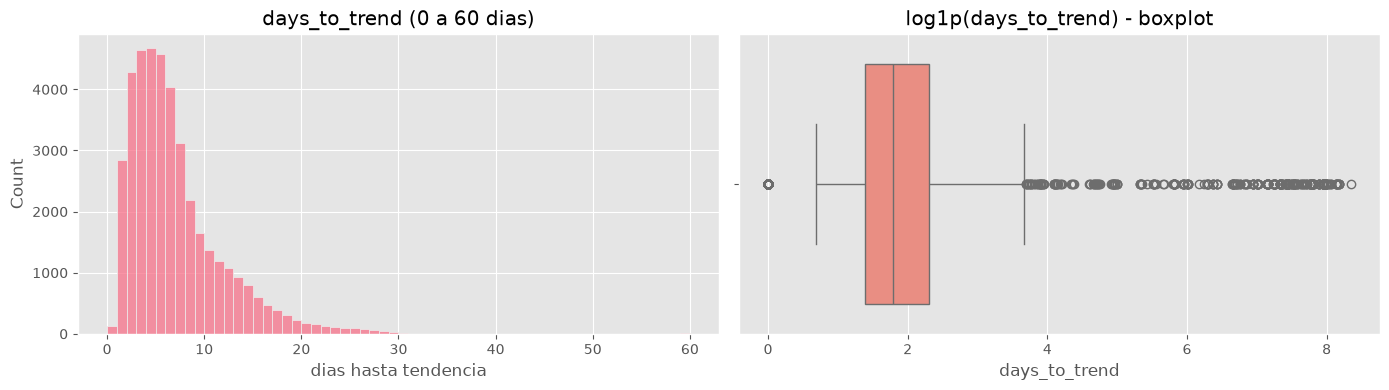

In [5]:
# Diagnostico de outliers de days_to_trend (antes de limpiar): IQR sobre valores >= 0
positivos = df.loc[df["days_to_trend"] >= 0, "days_to_trend"]
q1, q3 = positivos.quantile(0.25), positivos.quantile(0.75)
iqr = q3 - q1
lim_sup = q3 + 1.5 * iqr
print(f"Q1={q1:.0f}  Q3={q3:.0f}  IQR={iqr:.0f}  limite_sup={lim_sup:.0f}")
print(f"Extremos por encima del limite IQR: {int((positivos > lim_sup).sum())}")
print(f"Percentil 99 de days_to_trend: {positivos.quantile(0.99):.0f} dias")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(positivos[positivos <= 60], bins=60, ax=axes[0])
axes[0].set_title("days_to_trend (0 a 60 dias)")
axes[0].set_xlabel("dias hasta tendencia")
sns.boxplot(x=np.log1p(positivos), ax=axes[1], color="salmon")
axes[1].set_title("log1p(days_to_trend) - boxplot")
plt.tight_layout()
plt.show()

## 4. Consistencia: negativos y reglas de negocio

Primero descartamos los `days_to_trend` negativos (imposibles). Luego validamos las 5
reglas de negocio de `scripts/eda.py`, reportamos las violaciones por regla y
eliminamos las filas que las incumplan (datos inconsistentes).

In [6]:
# 4.1 Descartar days_to_trend negativos (imposibles)
antes = len(df)
df = df[df["days_to_trend"] >= 0].copy()
descartes["days_to_trend_negativos"] = antes - len(df)
print(f"Eliminados por days_to_trend negativo: {descartes['days_to_trend_negativos']}")
print(f"Filas restantes: {len(df):,}")

Eliminados por days_to_trend negativo: 0
Filas restantes: 40,899


In [7]:
# 4.2 Validacion de las 5 reglas de negocio (mascaras de VIOLACION)
def a_bool(serie):
    if serie.dtype == bool:
        return serie
    return serie.astype(str).str.strip().str.lower().isin(["true", "1", "yes"])

comments_disabled = a_bool(df["comments_disabled"])
ratings_disabled = a_bool(df["ratings_disabled"])

violaciones = {
    "R1a: likes > views": df["likes"] > df["views"],
    "R1b: dislikes > views": df["dislikes"] > df["views"],
    "R2: trending < publish (days<0)": df["days_to_trend"] < 0,
    "R3: comment_count > views": df["comment_count"] > df["views"],
    "R4: comments_disabled pero comment_count>0": comments_disabled & (df["comment_count"] > 0),
    "R5: ratings_disabled pero likes/dislikes>0": ratings_disabled & ((df["likes"] > 0) | (df["dislikes"] > 0)),
}

resumen_reglas = pd.DataFrame({"n_violaciones": {k: int(v.sum()) for k, v in violaciones.items()}})
resumen_reglas["%_violaciones"] = (resumen_reglas["n_violaciones"] / len(df) * 100).round(3)
resumen_reglas

,n_violaciones,%_violaciones
R1a: likes > views,0,0.0
R1b: dislikes > views,0,0.0
R2: trending < publish (days<0),0,0.0
R3: comment_count > views,0,0.0
R4: comments_disabled pero comment_count>0,0,0.0
R5: ratings_disabled pero likes/dislikes>0,0,0.0


In [8]:
# 4.3 Eliminar filas que violan al menos una regla
mascara_violacion = pd.concat(violaciones.values(), axis=1).any(axis=1)
antes = len(df)
df = df[~mascara_violacion].copy()
descartes["viola_reglas_negocio"] = antes - len(df)
print(f"Eliminados por violar alguna regla de negocio: {descartes['viola_reglas_negocio']}")
print(f"Filas restantes: {len(df):,}")

Eliminados por violar alguna regla de negocio: 0
Filas restantes: 40,899


## 5. Nulos

El único campo con nulos es `description` (~1.4%). Como no se usará como texto directo,
rellenamos con cadena vacía y dejamos una bandera `desc_faltante` por si aporta señal.
Verificamos que no queden nulos en las columnas que se usarán para modelar.

In [9]:
# Nulos antes del tratamiento
print("Nulos por columna (antes):")
print(df.isnull().sum()[df.isnull().sum() > 0])

# description: unico campo con vacios reales.
# Estrategia: rellenar con cadena vacia ("") y conservar una bandera que marque
# los registros que estaban vacios (desc_faltante), por si aporta senal al modelo.
df["desc_faltante"] = df["description"].isna()
df["description"] = df["description"].fillna("")
print("Descripciones vacias marcadas (desc_faltante=True):", int(df["desc_faltante"].sum()))

# Verificacion: columnas clave para modelar no deben tener nulos
cols_modelo = ["likes", "views", "dislikes", "comment_count", "days_to_trend", "category_name"]
print("\nNulos en columnas de modelado (deberian ser 0):")
print(df[cols_modelo].isnull().sum())

Nulos por columna (antes):
description    569
dtype: int64

Nulos en columnas de modelado (deberian ser 0):
likes            0
views            0
dislikes         0
comment_count    0
days_to_trend    0
category_name    0
dtype: int64


## 5.5 Checkpoint intermedio y re-análisis de variables

Punto de control entre la limpieza y la ingeniería de variables:

- **Persistimos el estado limpio** (`df_base`) y lo exportamos como CSV intermedio
  (`USvideos_clean_base.csv`) para poder retomar el análisis/modelado sin re-ejecutar.
- **Verificamos** que la limpieza funcionó (0 duplicados, 0 nulos en columnas de
  modelado, `days_to_trend >= 0`).
- **Re-analizamos** sobre datos limpios: distribución saneada de `days_to_trend` y
  matriz de correlación **actualizada incluyendo `days_to_trend`** (Pearson sobre
  `log1p` y Spearman por la asimetría).

> Recordatorio: no se eliminan outliers de las métricas de engagement (son videos
> virales reales); se tratan con `log1p`. El borrado aplicó solo a lo imposible.

In [10]:
# 5.5.1 Verificaciones de integridad post-limpieza
print("=== VERIFICACIONES POST-LIMPIEZA ===")
print("Duplicados exactos:", int(df.duplicated().sum()))
print("Duplicados (video_id, trending_date):", int(df.duplicated(subset=['video_id', 'trending_date']).sum()))
print("Nulos en columnas de modelado:", int(df[cols_modelo].isnull().sum().sum()))
print("days_to_trend negativos:", int((df['days_to_trend'] < 0).sum()))

# Persistir checkpoint en memoria y en disco
df_base = df.copy()
df_base.to_csv(CLEAN_BASE_PATH, index=False)
print(f"\nCheckpoint guardado en: {CLEAN_BASE_PATH}")
print(f"Filas en el checkpoint: {len(df_base):,}")

=== VERIFICACIONES POST-LIMPIEZA ===
Duplicados exactos: 0
Duplicados (video_id, trending_date): 0
Nulos en columnas de modelado: 0
days_to_trend negativos: 0

Checkpoint guardado en: d:\UPChexk\2026-I\Fundamentos_Data_Science\TFF\1ACC0216-TB2-2026-1\dataset\USvideos_clean_base.csv
Filas en el checkpoint: 40,899


In [ ]:
# 5.5.2 Distribucion de days_to_trend ya saneada
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["days_to_trend"], bins=60, ax=axes[0])
axes[0].set_title("days_to_trend (limpio) - escala normal")
axes[0].set_xlabel("dias hasta tendencia")
sns.histplot(np.log1p(df["days_to_trend"]), bins=60, ax=axes[1], color="seagreen")
axes[1].set_title("log1p(days_to_trend)")
plt.tight_layout()
plt.show()

print(df["days_to_trend"].describe())

In [ ]:
# 5.5.3 Matriz de correlacion actualizada incluyendo days_to_trend
vars_corr = ["likes", "views", "dislikes", "comment_count", "days_to_trend"]
log_corr = np.log1p(df[vars_corr]).add_prefix("log_")

corr_pearson = log_corr.corr(method="pearson")
corr_spearman = df[vars_corr].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=axes[0])
axes[0].set_title("Pearson (log1p)")
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title("Spearman (rangos)")
plt.tight_layout()
plt.show()

## 6. Ingeniería de variables

Construimos las variables derivadas para el modelo de `likes`:

- `first_trend` (bool): primera aparición de cada `video_id` en el panel.
- Ratios: `dislike_view_ratio`, `comment_view_ratio`.
- Transformaciones log: `log_likes` (target), `log_views`, `log_dislikes`,
  `log_comments`, `log_days_to_trend`.
- Derivadas de texto de bajo costo: `title_length`, `n_tags`.
- Codificación de `category_name` (códigos) para el modelo; se descarta `category_id`.

### 6.0 Tratamiento de outliers (winsorización)

Los extremos de las métricas numéricas suelen ser **videos virales reales**, así que no
eliminamos filas. En su lugar aplicamos **winsorización**: recortamos (clip) cada variable
a su rango `[p1, p99]`, creando columnas `*_cap`. Esto reduce el apalancamiento de los
valores atípicos sin perder registros.

- Se capean los **predictores** numéricos: `views`, `dislikes`, `comment_count`, `days_to_trend`.
- El **target** `likes` **no** se capea; su sesgo se controla con `log1p` (`log_likes`).
- Las transformaciones `log_*` y los ratios se derivan de las columnas capadas (ver 6.2).

In [ ]:
# 6.0 Winsorizacion: recorta extremos a [p1, p99] sin eliminar filas.
# Solo predictores numericos; el target 'likes' se deja intacto.
vars_cap = ["views", "dislikes", "comment_count", "days_to_trend"]

resumen_cap = []
for col in vars_cap:
    p01, p99 = df[col].quantile([0.01, 0.99])
    n_low = int((df[col] < p01).sum())
    n_high = int((df[col] > p99).sum())
    df[col + "_cap"] = df[col].clip(lower=p01, upper=p99)
    resumen_cap.append({
        "variable": col, "p01": round(p01, 2), "p99": round(p99, 2),
        "n_bajo_p01": n_low, "n_sobre_p99": n_high,
        "%_recortado": round((n_low + n_high) / len(df) * 100, 2),
    })

resumen_cap = pd.DataFrame(resumen_cap)
print("Filas (sin cambios, winsorizar no elimina):", f"{len(df):,}")
resumen_cap

In [ ]:
# Efecto del cap: boxplots antes/despues en escala log1p (compacto)
fig, axes = plt.subplots(1, len(vars_cap), figsize=(15, 4))
for ax, col in zip(axes, vars_cap):
    comp = pd.DataFrame({
        "antes": np.log1p(df[col]),
        "despues": np.log1p(df[col + "_cap"]),
    })
    sns.boxplot(data=comp, ax=ax)
    ax.set_title(col)
    ax.set_ylabel("log1p")
plt.suptitle("Outliers antes vs despues de winsorizar (p1-p99)", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# 6.1 first_trend: primera aparicion de cada video en el panel
primera_fecha = df.groupby("video_id")["trending_date"].transform("min")
df["first_trend"] = df["trending_date"].eq(primera_fecha)
print("Distribucion de first_trend:")
print(df["first_trend"].value_counts())

### 6.5 Categoría agrupada por impacto (one-hot)

En lugar de un `category_code` ordinal (que impondría distancias falsas entre categorías) o
de un one-hot de las 16 categorías (~15 dummies), agrupamos las categorías en **4 niveles
según su impacto** en `log_likes` y aplicamos one-hot (referencia = `Bajo`, quedan 3 dummies).

Justificación cuantitativa (medida con `eta² = SS_between / SS_total` sobre `log_likes`):

- 16 categorías: eta² = **0.153**
- 4 grupos: eta² = **0.144** -> se conserva **~94%** del poder discriminante con solo **3 dummies**.

Los grupos tienen escalones limpios (~1 unidad log de separación entre niveles consecutivos):

| Grupo | media log_likes | mediana likes | Categorías |
|---|---|---|---|
| Alto | 10.58 | ~46k | Music, Gaming, Comedy |
| MedioAlto | 9.53 | ~17k | Entertainment, Howto & Style, Film & Animation, People & Blogs, Education, Science & Technology, Pets & Animals, Shows |
| MedioBajo | 8.61 | ~6.3k | Sports, Travel & Events |
| Bajo | 7.46 | ~2.2k | News & Politics, Autos & Vehicles, Nonprofits & Activism |

Cada coeficiente del modelo se interpretará como los likes extra (en escala log) frente al
grupo de referencia `Bajo`. Nota: el mapeo se fija a partir del comportamiento observado; en
un pipeline con partición train/test, la definición de grupos debería fijarse con el train.

In [ ]:
# 6.2 Ratios validos (SIN 'likes' en el numerador para evitar leakage con el target)
# Se calculan sobre las columnas capadas (winsorizadas) para ser consistentes con el modelado.
# views_cap > 0 en todo el dataset, pero usamos un guard por robustez.
denom = df["views_cap"].replace(0, np.nan)
df["dislike_view_ratio"] = (df["dislikes_cap"] / denom).fillna(0)
df["comment_view_ratio"] = (df["comment_count_cap"] / denom).fillna(0)

# NOTA: like_view_ratio = likes/views se OMITE deliberadamente (leakage con target=likes).

# 6.3 Transformaciones logaritmicas (log_likes es el target)
# Los predictores usan las versiones capadas; el target 'likes' se deja SIN capear.
df["log_likes"] = np.log1p(df["likes"])          # TARGET (sin cap; log controla el sesgo)
df["log_views"] = np.log1p(df["views_cap"])
df["log_dislikes"] = np.log1p(df["dislikes_cap"])
df["log_comments"] = np.log1p(df["comment_count_cap"])
df["log_days_to_trend"] = np.log1p(df["days_to_trend_cap"])

# 6.4 Derivadas de texto de bajo costo (no leaky)
df["title_length"] = df["title"].astype(str).str.len()
df["n_tags"] = df["tags"].astype(str).apply(
    lambda t: 0 if t.strip() in ("", "[none]") else len(t.split("|"))
)

# 6.5 Categoria agrupada por impacto (4 grupos) + one-hot (referencia = Bajo)
# Agrupamos las 16 categorias en 4 niveles por su impacto en log_likes. Esto evita el
# category_code ordinal (inapropiado para regresion lineal) y reduce ~15 dummies a 3,
# conservando ~94% del poder discriminante (eta2 0.153 -> 0.144). Ver justificacion arriba.
GRUPO_CATEGORIA = {
    "Music": "Alto", "Gaming": "Alto", "Comedy": "Alto",
    "Entertainment": "MedioAlto", "Howto & Style": "MedioAlto",
    "Film & Animation": "MedioAlto", "People & Blogs": "MedioAlto",
    "Education": "MedioAlto", "Science & Technology": "MedioAlto",
    "Pets & Animals": "MedioAlto", "Shows": "MedioAlto",
    "Sports": "MedioBajo", "Travel & Events": "MedioBajo",
    "News & Politics": "Bajo", "Autos & Vehicles": "Bajo",
    "Nonprofits & Activism": "Bajo",
}
ORDEN_GRUPOS = ["Bajo", "MedioBajo", "MedioAlto", "Alto"]

df["cat_grupo"] = pd.Categorical(
    df["category_name"].map(GRUPO_CATEGORIA), categories=ORDEN_GRUPOS, ordered=True
)
dummies = pd.get_dummies(df["cat_grupo"], prefix="catgrupo")
dummies = dummies.drop(columns=["catgrupo_Bajo"]).astype(int)  # Bajo = referencia
df = pd.concat([df, dummies], axis=1)
cols_catgrupo = list(dummies.columns)

# Verificacion: ninguna categoria quedo sin mapear
sin_mapear = int(df["cat_grupo"].isna().sum())
print("Categorias sin mapear a grupo (deberia ser 0):", sin_mapear)
print("Dummies one-hot creadas:", cols_catgrupo)

print("\nNuevas variables creadas:")
print(df[["first_trend", "dislike_view_ratio", "comment_view_ratio",
          "log_likes", "log_views", "log_dislikes", "log_comments",
          "log_days_to_trend", "title_length", "n_tags", "cat_grupo"] + cols_catgrupo].head())

## 7. Selección de columnas y exportación

Descartamos columnas inservibles para modelar (identificadores únicos, geografía
aleatoria, textos crudos ya resumidos y columnas cuasi-constantes/redundantes),
conservamos identificadores solo para trazabilidad, y exportamos el dataset final
listo para modelar `likes`. Cerramos con un reporte de filas eliminadas por motivo.

In [ ]:
# 7.1 Definir columnas a conservar en el dataset model-ready
cols_id = ["video_id", "trending_date"]           # solo trazabilidad, NO features
col_target = ["likes", "log_likes"]                # target (crudo y log)
cols_features = [
    # numericas crudas (engagement, sin 'likes') - se conservan para trazabilidad
    "views", "dislikes", "comment_count", "days_to_trend",
    # versiones winsorizadas (cap p1-p99) usadas para derivar log_* y ratios
    "views_cap", "dislikes_cap", "comment_count_cap", "days_to_trend_cap",
    # transformaciones log (derivadas de las capadas)
    "log_views", "log_dislikes", "log_comments", "log_days_to_trend",
    # ratios validos (no contienen likes)
    "dislike_view_ratio", "comment_view_ratio",
    # derivadas de texto / temporales / categoria
    "title_length", "n_tags", "first_trend", "desc_faltante",
    "category_name", "cat_grupo",   # trazabilidad de la categoria (NO features del modelo)
    *cols_catgrupo,                 # one-hot de la categoria agrupada por impacto (features)
    # banderas de estado del video
    "comments_disabled", "ratings_disabled",
]

cols_finales = cols_id + col_target + cols_features
df_model = df[cols_finales].copy()

# Columnas descartadas explicitamente (para el reporte)
cols_descartadas = [c for c in df.columns if c not in cols_finales]
print("Columnas conservadas:", len(cols_finales))
print("Columnas descartadas:", cols_descartadas)
df_model.head()

In [ ]:
# 7.2 Verificacion final de nulos (no deben quedar vacios en el dataset model-ready)
n_nulos = int(df_model.isnull().sum().sum())
assert n_nulos == 0, f"Hay {n_nulos} nulos en el dataset final"
print("Nulos totales en el dataset final:", n_nulos)

# 7.3 Exportar dataset final (model-ready)
df_model.to_csv(CLEAN_MODEL_PATH, index=False)
print(f"Dataset model-ready guardado en: {CLEAN_MODEL_PATH}")
print(f"Dimensiones finales: {df_model.shape[0]:,} filas x {df_model.shape[1]} columnas")

In [ ]:
# 7.3 Reporte final de la limpieza
total_eliminadas = sum(descartes.values())
print("=== REPORTE DE LIMPIEZA ===")
print(f"Filas iniciales: {n_filas_inicial:,}")
for motivo, n in descartes.items():
    print(f"  - {motivo}: {n}")
print(f"Total eliminadas: {total_eliminadas}")
print(f"Filas finales: {len(df_model):,}  "
      f"({len(df_model) / n_filas_inicial * 100:.2f}% del original)")

print("\nOutliers: tratados por WINSORIZACION (cap p1-p99) como transformacion, "
      "0 filas eliminadas por outliers.")
print(f"  Variables capadas: {', '.join(vars_cap)}")
print("Vacios: description rellenada con \"\" + bandera desc_faltante; nulos finales = 0.")
print(f"Categoria: one-hot de 4 grupos por impacto ({', '.join(cols_catgrupo)}; ref=Bajo), "
      f"reemplaza a category_code ordinal.")
print(f"\nTarget: likes (log_likes). Features: {len(cols_features)}. "
      f"Ratios con leakage excluidos: like_view_ratio.")